#🎯 Medidas de Tendência Central

Imagine que você tem os custos de procedimentos hospitalares.

A pergunta não é:
"Quais são todos os valores?"

Mas sim:
- Qual é o valor típico?
- Qual número representa melhor esse conjunto?

É isso que as medidas de tendência central fazem:
→ resumem o dado em um único valor representativo

#❤️ Criando um dataset de exemplo em saúde

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

# ---------------------------------
# 1. BASE BIMODAL CONTROLADA
# ---------------------------------

# dois grupos bem separados
grupo_1 = np.random.normal(loc=200, scale=25, size=400)
grupo_2 = np.random.normal(loc=800, scale=25, size=400)

# pequena cauda alta para assimetria
grupo_3 = np.random.normal(loc=2500, scale=400, size=40)

custos_base = np.concatenate([grupo_1, grupo_2, grupo_3])
custos_base = np.abs(custos_base)

# arredondar para múltiplos de 10
custos_base = (custos_base / 10).round() * 10

df = pd.DataFrame({"custo": custos_base})

# ---------------------------------
# 2. GARANTIR DUAS MODAS EXATAS
# ---------------------------------

# remover todos os 200 e 800 que surgiram naturalmente
df = df[~df["custo"].isin([200, 800])].copy().reset_index(drop=True)

# adicionar exatamente a mesma quantidade de 200 e 800
moda_200 = pd.DataFrame({"custo": [200] * 180})
moda_800 = pd.DataFrame({"custo": [800] * 180})

df = pd.concat([df, moda_200, moda_800], ignore_index=True)

In [ ]:
df.tail()

,custo
1069,800.0
1070,800.0
1071,800.0
1072,800.0
1073,800.0


In [ ]:
df.shape

(1074, 1)

# 📊 Média

A média é a soma dos valores dividida pela quantidade de observações.

Ela representa o "equilíbrio" dos dados.

In [ ]:
media = df["custo"].mean()
media

np.float64(574.1899441340782)

# 📊 Mediana

A mediana é o valor central após ordenar os dados.

Ela representa o ponto onde metade dos dados está acima e metade abaixo.

In [ ]:
mediana = df["custo"].median()
mediana

760.0

# 📊 Moda

A moda é o valor que mais se repete.

In [ ]:
moda = df["custo"].mode()
moda

,custo
0,200.0
1,800.0


#  🆚 Comparando média, mediana e moda

- Média → sensível a valores extremos
- Mediana → resistente a outliers
- Moda → mostra padrão mais frequente

Pergunta prática:
qual dessas representa melhor o dado?

In [ ]:
print("Média:", media)
print("Mediana:", mediana)
print("Moda:", moda.tolist())

Média: 574.1899441340782
Mediana: 760.0
Moda: [200.0, 800.0]


In [ ]:
import plotly.express as px
import plotly.graph_objects as go

media = df["custo"].mean()
mediana = df["custo"].median()
modas = df["custo"].mode().tolist()

df_plot = df[df["custo"] <= 1200].copy()

fig = px.histogram(
    df_plot,
    x="custo",
    nbins=40,
    opacity=0.8,
    title="Distribuição bimodal de custos"
)

# linhas
fig.add_vline(x=media, line_dash="dash", line_width=3)
fig.add_vline(x=mediana, line_dash="solid", line_width=3)

for m in modas:
    fig.add_vline(x=m, line_dash="dot", line_width=3)

# anotações mais organizadas
fig.add_annotation(x=media, y=0.98, xref="x", yref="paper",
                   text=f"Média = {media:.0f}", showarrow=False)
fig.add_annotation(x=mediana, y=0.90, xref="x", yref="paper",
                   text=f"Mediana = {mediana:.0f}", showarrow=False)

if len(modas) > 0:
    fig.add_annotation(x=modas[0], y=1.06, xref="x", yref="paper",
                       text=f"Moda 1 = {modas[0]:.0f}", showarrow=False)

if len(modas) > 1:
    fig.add_annotation(x=modas[1], y=1.14, xref="x", yref="paper",
                       text=f"Moda 2 = {modas[1]:.0f}", showarrow=False)

fig.update_layout(
    xaxis_title="Custo",
    yaxis_title="Frequência",
    bargap=0.03,
    height=550,
    template="plotly_white",
    title_x=0.5
)

fig.show()

👉 Interpretação: A distribuição de custos não é única. Existem dois padrões principais, representados pelas modas em torno de 200 e 800 (multimodal ou, no caso, bimodal), provavelmente dado por procedimentos clínicos, tipicamente mais baratos, e procedimentos mais caros, tipicamente cirúrgicos.

👉 A mediana indica que metade dos atendimentos já está mais próxima do grupo intermediário.
Já a média fica entre os grupos, mas não representa bem nenhum deles.

In [ ]:
fig = px.box(
    df,
    x="custo",
    points="outliers",
    title="Boxplot dos custos"
)

fig.update_layout(
    template="plotly_white",
    height=400,
    title_x=0.5
)

fig.show()

Além disso, o boxplot mostra uma cauda de valores altos, indicando poucos casos muito caros, algo típico em saúde, que puxam a mediana para cima.

#  📐 Grau de assimetria (Skewness)

Com base no deslocamento dos valores das medidas de tendência central, podemos ter uma distribuição simétrica ou assimétrica (negativa ou à esquerda, positiva ou à direita)


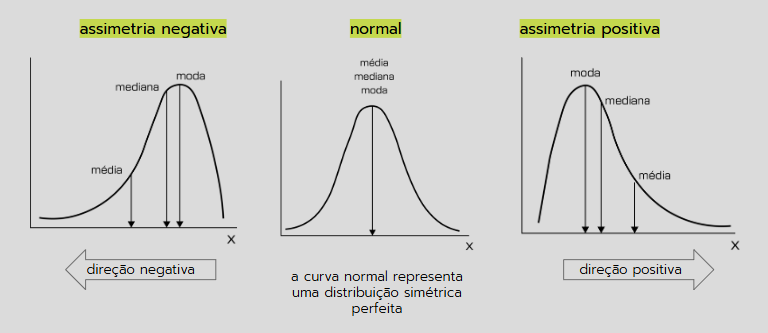

# 📊 Medidas de Tendência Central Adicionais

### 📌 Média ponderada

Quando usar: Quando os valores têm “peso” diferente.

In [ ]:
# exemplo: quantidade de procedimentos
df["quantidade"] = np.random.randint(1, 10, size=len(df))

In [ ]:
df.head(3)

,custo,quantidade
0,210.0,3
1,220.0,9
2,240.0,5


In [ ]:
media_ponderada = np.average(df["custo"], weights=df["quantidade"])

print(f"Média ponderada: {media_ponderada:.2f}")

Média ponderada: 563.32


Dessa forma, procedimentos mais frequentes influenciam mais o custo médio.

### 📌 Média geométrica

* Intuição forte: A média geométrica responde: “Qual foi o crescimento médio consistente ao longo do tempo?”


* Como pensar (sem fórmula): Imagine que os valores se multiplicam entre si, não se somam. Exemplo: um custo cresce 20%, depois cai 10%, depois cresce 30%. A média aritmética não representa bem isso. A geométrica representa o “ritmo médio real”

* O que ela faz na prática: reduz o impacto de valores extremos, “puxa para baixo” valores muito altos, funciona melhor quando existe assimetria (como no seu gráfico)

* Interpretação em saúde: crescimento de custo ao longo do tempo, evolução de gasto por paciente, análise de risco, custos acumulados, etc. Ela responde: “Qual o comportamento típico de crescimento?”

* Limitação importante: não funciona com valores negativos ou zero, exige dados positivos

In [ ]:
from scipy.stats import gmean

# evitar zero
custos_positivos = df["custo"][df["custo"] > 0]

media_geometrica = gmean(custos_positivos)

print(f"Média geométrica: {media_geometrica:.2f}")

Média geométrica: 425.67


### 📌 Média harmônica

* Intuição principal: A média harmônica responde:
“Qual é a média quando os valores estão no denominador?”

* Tradução prática: Ela é usada quando você está lidando com razões ou taxas, como: custo por evento, tempo por atendimento, velocidade, produtividade

* Como pensar (sem fórmula): Imagine isso. Você quer saber o “custo médio por consulta”, mas cada consulta tem peso diferente no total. A média harmônica ajusta isso automaticamente

* Insight chave: A média harmônica dá mais peso para valores pequenos.

* Quando usar: use média harmônica quando está lidando com: custo por unidade, taxa por evento, tempo por procedimento

* Não use quando os dados são valores absolutos simples e existem zeros ou negativos

In [ ]:
from scipy.stats import hmean

media_harmonica = hmean(custos_positivos)

print(f"Média harmônica: {media_harmonica:.2f}")

Média harmônica: 326.94


Dá mais peso para valores pequenos.

👉 exemplo saúde: custo por consulta, tempo médio por atendimento

### 📌 Trimmed mean (média aparada)

* Intuição principal: “Qual é a média se eu ignorar os extremos?”

* Como pensar (forma simples): Você pega os dados e corta uma parte dos menores valores, corta uma parte dos maiores valores e calcula a média do que sobrou

* Exemplo rápido: Trim de 10%, remove 5% mais baixos, remove 5% mais altos e sobra o “miolo” da distribuição

* O que ela resolve: No seu caso existem custos muito altos (outliers), a média sobe artificialmente. A trimmed mean corrige isso

* Interpretação em saúde: Ela responde: “Qual é o custo típico ignorando casos extremos?”. Muito útil para: gestão operacional, contratos com operadoras, análise de custo médio “realista”

* Insight chave: A trimmed mean reduz o impacto dos extremos. Dependendo da distribuição, ela pode ficar abaixo ou acima da média.

| Medida       | Comportamento              |
| ------------ | -------------------------- |
| Média        | Sensível a extremos        |
| Mediana      | Ignora extremos            |
| Trimmed Mean | Reduz impacto dos extremos |


In [ ]:
from scipy.stats import trim_mean

custos = df["custo"]

# remover 10% (5% de cada lado)
media_aparada = trim_mean(custos, proportiontocut=0.1)

print(f"Trimmed Mean (10%): {media_aparada:.2f}")

Trimmed Mean (10%): 512.44


### 🔥 Comparação direta

In [ ]:
from scipy.stats import gmean, hmean

custos_positivos = df["custo"][df["custo"] > 0]

resumo = pd.DataFrame({
    "Métrica": [
        "Mediana",
        "Média Aritmética",
        "Média aparada",
        "Média Geométrica",
        "Média Harmônica"
    ],
    "Valor": [
        custos_positivos.median(),
        custos_positivos.mean(),
        trim_mean(custos, proportiontocut=0.1),
        gmean(custos_positivos),
        hmean(custos_positivos)
    ]
})

resumo

,Métrica,Valor
0,Mediana,760.000000
1,Média Aritmética,574.189944
2,Média aparada,512.441860
3,Média Geométrica,425.667834
4,Média Harmônica,326.939450


💡 Geralmenete: Harmônica < Geométrica < Aparada < Aritmética < Mediana. Mas não existe regra fixa de posição. A relação depende de: assimetria, presença de outliers e proporção entre grupos.

🎯 “Não existe uma média melhor. Existe a média certa para o problema.”

* média aritmética → centro matemático
* mediana → centro real
* média aparada → reduz o efeito dos extremos.
* geométrica → reduz impacto da cauda dos valores mais altos, ideal para crescimento (crescimento médio)
* harmônica → aproxima do custo típico mais baixo, ideal para razões e taxas (taxa média)